In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


In [5]:
df=pd.read_csv('Bumble.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   gender       59946 non-null  object 
 3   body_type    54650 non-null  object 
 4   diet         35551 non-null  object 
 5   drinks       56961 non-null  object 
 6   education    53318 non-null  object 
 7   ethnicity    54266 non-null  object 
 8   height       59943 non-null  float64
 9   income       59946 non-null  int64  
 10  job          51748 non-null  object 
 11  last_online  59946 non-null  object 
 12  location     59946 non-null  object 
 13  pets         40025 non-null  object 
 14  religion     39720 non-null  object 
 15  sign         48890 non-null  object 
 16  speaks       59896 non-null  object 
dtypes: float64(1), int64(2), object(14)
memory usage: 7.8+ MB


In [7]:
df.describe()

,age,height,income
count,59946.000000,59943.000000,59946.000000
mean,32.340290,68.295281,20033.222534
std,9.452779,3.994803,97346.192104
min,18.000000,1.000000,-1.000000
25%,26.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,37.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


PART 1 DATA CLEANING 

1.1 Inspecting Missing Data

In [8]:
# Q1. Which columns in the dataset have missing values, and what percentage of data is missing in each column?

In [9]:
df.head()

missing_data = df.isnull().mean() * 100
missing_data = missing_data.sort_values(ascending=False)

print(missing_data)

diet           40.694959
religion       33.740366
pets           33.231575
sign           18.443266
job            13.675641
education      11.056618
ethnicity       9.475194
body_type       8.834618
drinks          4.979482
speaks          0.083408
height          0.005005
last_online     0.000000
location        0.000000
income          0.000000
status          0.000000
gender          0.000000
age             0.000000
dtype: float64


In [14]:
#Q2.Are there columns where more than 50% of the data is missing? Would you drop those columns where missing values are >50%. If yes, why?

In [11]:
high_missing = missing_data[missing_data > 50]
print(high_missing)

Series([], dtype: float64)


In [ ]:
- No, there are no columns where more than 50% of data is missing. If there were more than 50% we would exclude that as they are considered unreliable.

In [ ]:
# Q3. How would you handle the missing numerical data (e.g., height, income)? Would you impute the missing data by the median or average value of 
#     height and income for the corresponding category, such as gender, age group, or location. If yes, why?

In [ ]:
*By imputing the missing values 
*For height column we would use the median or mean as number of missing values is very scarce.
*For income column the only part of concern is (-1) value and income data has differnce which is huge so we would use median imputation


1.2. Data Types

In [ ]:
# Q1. Are there any inconsistencies in the data types across columns (e.g., numerical data stored as strings)?

In [ ]:
*Most columns have almost accurate data types except the last_online column is stored as a string and should ideally be converted into datetime.
*Income  is stored as integer, but will be converted into float after converting (-1) value to NaN values.

In [ ]:
# Q2. Which columns require conversion to numerical data types for proper analysis (e.g., income)?

In [ ]:
None of them requires conversion to numerical data types

In [ ]:
# Q3. Does the last_online column need to be converted into a datetime format? What additional insights can be gained by analyzing this as a date field?

In [ ]:
Yes, the last_online coulmn should be converted into datetime format
* It can help in tracking the trends of a particular user
* It can help in extracting the last time when user was active on the platform

In [ ]:
Converting last_online to Datetime

In [20]:
df['last_online'] = pd.to_datetime(df['last_online'], format = '%Y-%m-%d-%H-%M')

In [21]:
df['last_online'].head(5)

0   2012-06-28 20:30:00
1   2012-06-29 21:41:00
2   2012-06-27 09:10:00
3   2012-06-28 14:22:00
4   2012-06-27 21:26:00
Name: last_online, dtype: datetime64[ns]

1.3 Outliers

In [ ]:
# Q1. Are there any apparent outliers in numerical columns such as age, height, or income? What are the ranges of values in these columns?

In [24]:
df[['age','height','income']].describe()

,age,height,income
count,59946.000000,59943.000000,59946.000000
mean,32.340290,68.295281,20033.222534
std,9.452779,3.994803,97346.192104
min,18.000000,1.000000,-1.000000
25%,26.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,37.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


In [25]:
df[['age','height','income']].agg(['min','max'])

,age,height,income
min,18,1.0,-1
max,110,95.0,1000000


In [ ]:
# Q2. Any -1 values in numerical columns like income should be replaced with blank, as they may represent missing or invalid data.

In [26]:
df['income'] = df['income'].replace(-1, np.nan)

In [ ]:
# Q3. For other outliers, how would you ensure that they o not disproportionately impact the analysis while retaining as much meaningful data as possible. Would you delete the data or rather than deleting them, calculate the mean and median values using only the middle 80% of the data (removing extreme high and low values). Provide appropriate reasons for every step.

In [27]:
lower = df['income'].quantile(0.10)
upper = df['income'].quantile(0.90)

df_income_filtered = df[(df['income'] >= lower) & (df['income'] <= upper)]

In [30]:
income_null_percentage = df['income'].isnull().mean() * 100
print(income_null_percentage)

80.80939512227671


1.4 Missing Data Visualisation 

In [ ]:
# Q1. Create a heatmap to visualize missing values across the dataset. Which columns show consistent missing data patterns?

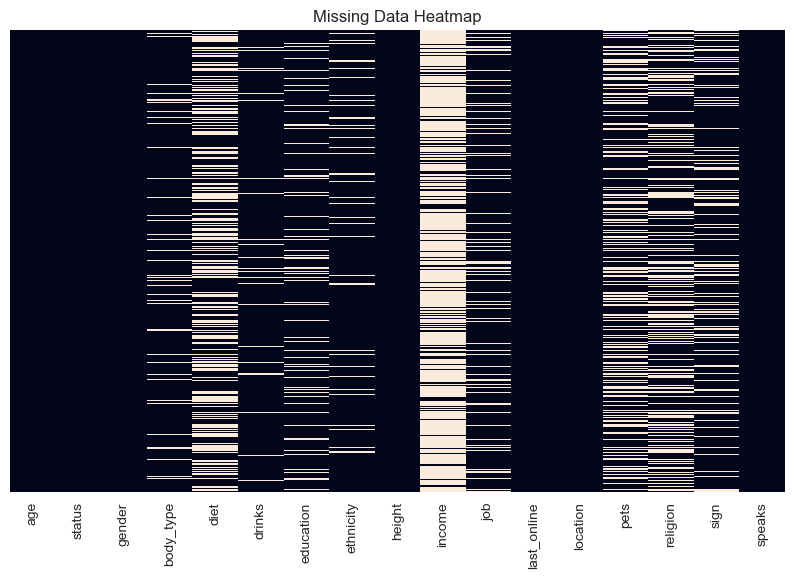

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Data Heatmap")
plt.show()

PART 2 DATA PROCESSING

1. Binning and Grouping

In [ ]:
# Q1.How would you bin the age column into categories (e.g. "18-25", "26-35", "36-45", and "46+" ) to create a new column, age_group. How does the distribution of users vary across these age ranges?

In [37]:
bins = [18, 25, 35, 45, 100]
labels = ['18-25', '26-35', '36-45', '46+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [39]:
df['age_group'].value_counts()

age_group
26-35    28621
18-25    14145
36-45    10803
46+       6066
Name: count, dtype: int64

In [40]:
df['age_group'].value_counts().sort_index()

age_group
18-25    14145
26-35    28621
36-45    10803
46+       6066
Name: count, dtype: int64

In [ ]:
* Majority of users are typically in 18–25 and 26–35 groups and fewer users in older categories (36+)

In [ ]:
# Q2. Group income into categories like "Low Income," "Medium Income," and "High Income" based on meaningful thresholds (e.g., quartiles). What insights can be derived from these groups?

In [42]:
df['income_group'] = pd.qcut(df['income'], q=3, 
labels=['Low Income', 'Medium Income', 'High Income'])

In [43]:
df['income_group'].value_counts()

income_group
Medium Income    4534
Low Income       4000
High Income      2970
Name: count, dtype: int64

In [44]:
df['income_group'].value_counts().sort_index()

income_group
Low Income       4000
Medium Income    4534
High Income      2970
Name: count, dtype: int64

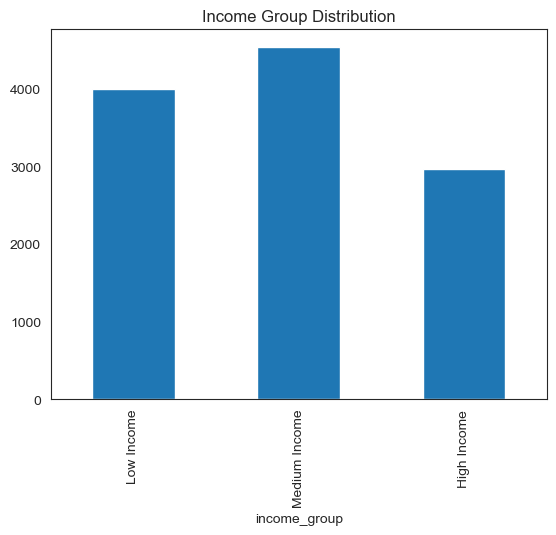

In [49]:
df['income_group'].value_counts().sort_index().plot(kind='bar')
plt.title("Income Group Distribution")
plt.show()

In [ ]:
* The highest number is with the medium  income level followed with the low income groups.
* There is lesser number in higher income group as compared to other two groups.

2. Dervied Features

In [ ]:
# Q1. Create a new feature, profile_completeness, by calculating the percentage of non-missing values for each user profile. How complete are most user profiles, and how does completeness vary across demographics?

In [50]:
# Percentage of non-missing values per user
df['profile_completeness'] = df.notnull().mean(axis=1) * 100

In [51]:
df['profile_completeness'].describe()

count    59946.000000
mean        82.296962
std         10.237551
min         36.842105
25%         78.947368
50%         84.210526
75%         89.473684
max        100.000000
Name: profile_completeness, dtype: float64

3. Unit Conversion

In [ ]:
# Q1. Convert the height column from inches to centimeters using the conversion factor (1 inch = 2.54 cm). Store the converted values in a new column, height_cm.

In [52]:
df['height_cm'] = df['height'] * 2.54

In [54]:
df[['height', 'height_cm']].head()

,height,height_cm
0,75.0,190.50
1,70.0,177.80
2,68.0,172.72
3,71.0,180.34
4,66.0,167.64


PART 3 DATA ANALYSIS

1. Demographic Analysis

In [ ]:
# Q1. What is the gender distribution (gender) across the platform? Are there any significant imbalances?

In [56]:
df['gender'].value_counts(normalize=True) * 100

gender
m    59.768792
f    40.231208
Name: proportion, dtype: float64

In [ ]:
* Male users seems to little extra with almost 60% of the total users
* Female users are lesser in number with 40% of the users
* This shows lil imbalance betweeen both the users.

In [ ]:
# Q2. What are the proportions of users in different status categories (e.g., single, married, seeing someone)? What does this suggest about the platform’s target audience?

In [57]:
df['status'].value_counts(normalize=True) * 100

status
single            92.911954
seeing someone     3.443099
available          3.111133
married            0.517132
unknown            0.016682
Name: proportion, dtype: float64

In [ ]:
* Majority of the users on the platform are single with almost 93% of it which is a good point for the platform.

In [ ]:
# Q3. How does status vary by gender? For example, what proportion of men and women identify as single?

In [58]:
pd.crosstab(df['gender'], df['status'], normalize='index') * 100

status,available,married,seeing someone,single,unknown
gender,,,,,
f,2.720073,0.559771,4.158892,92.544678,0.016586
m,3.374362,0.488431,2.961288,93.159173,0.016746


In [ ]:
* Men   = Almost 94%
* Women = Almost 93%

2. Correlation Analysis

In [ ]:
# Q1.What are the correlations between numerical columns such as age, income, gender Are there any strong positive or negative relationships?

In [59]:
df[['age','height','income']].corr()

,age,height,income
age,1.000000,-0.022262,-0.009234
height,-0.022262,1.000000,0.058829
income,-0.009234,0.058829,1.000000


In [ ]:
# Q2. How does age correlate with income? Are older users more likely to report higher income levels?

In [65]:
df[['age','income']].corr()

,age,income
age,1.000000,-0.009234
income,-0.009234,1.000000


3. Diet and Lifestyle Analysis

In [ ]:
# Q1. How do dietary preferences (diet) distribute across the platform? For example, what percentage of users identify as vegetarian, vegan, or follow "anything" diets?

In [68]:
df['diet'].value_counts(normalize=True) * 100

diet
mostly anything        46.651290
anything               17.391916
strictly anything      14.382155
mostly vegetarian       9.687491
mostly other            2.832550
strictly vegetarian     2.461253
vegetarian              1.876178
strictly other          1.271413
mostly vegan            0.950747
other                   0.931057
strictly vegan          0.641332
vegan                   0.382549
mostly kosher           0.241906
mostly halal            0.135017
strictly halal          0.050631
strictly kosher         0.050631
halal                   0.030941
kosher                  0.030941
Name: proportion, dtype: float64

In [ ]:
* Majority of users have flexible eating habits

In [ ]:
# Q2. How do drinking habits (drinks) vary across different diet categories? Are users with stricter diets (e.g., vegan) less likely to drink?

In [70]:
pd.crosstab(df['diet'], df['drinks'], normalize='index') * 100

drinks,desperately,not at all,often,rarely,socially,very often
diet,,,,,,
anything,0.350467,4.923231,9.579439,8.511348,75.667557,0.967957
halal,0.000000,44.444444,11.111111,0.000000,44.444444,0.000000
kosher,0.000000,9.090909,0.000000,18.181818,63.636364,9.090909
mostly anything,0.406479,5.185687,8.536060,9.466034,75.611258,0.794482
mostly halal,6.976744,23.255814,4.651163,18.604651,37.209302,9.302326
mostly kosher,1.190476,8.333333,4.761905,20.238095,59.523810,5.952381
mostly other,0.820513,9.333333,5.025641,18.051282,66.256410,0.512821
mostly vegan,0.621118,12.422360,6.832298,19.254658,59.937888,0.931677
mostly vegetarian,0.572117,5.871725,7.015959,14.031918,71.906052,0.602228


4. Geographical Insights

In [ ]:
# Q1. Extract city and state information from the location column. What are the top 5 cities and states with the highest number of users?

In [71]:
df[['city','state']] = df['location'].str.split(",", n=1, expand=True)

In [72]:
df['city'].value_counts().head(5)

city
san francisco    31064
oakland           7214
berkeley          4212
san mateo         1331
palo alto         1064
Name: count, dtype: int64

In [73]:
df['state'].value_counts().head(5)

state
california       59855
new york            17
illinois             8
massachusetts        5
texas                4
Name: count, dtype: int64

In [ ]:
# Q2. How does age vary across the top cities? Are certain cities dominated by younger or older users?

In [74]:
top_cities = df['city'].value_counts().head(5).index

In [78]:
df_top = df[df['city'].isin(top_cities)]

In [80]:
(pd.crosstab(df_top['city'], df_top['age_group'], normalize='index') * 100).round(2)

age_group,18-25,26-35,36-45,46+
city,,,,
berkeley,33.27,42.48,13.10,11.15
oakland,19.25,48.77,21.47,10.52
palo alto,28.02,46.13,13.49,12.36
san francisco,21.98,52.99,18.53,6.51
san mateo,21.51,45.89,18.72,13.89


In [ ]:
# Q3. What are the average income levels in the top states or cities? Are there regional patterns in reported income?

In [84]:
df_top.groupby('city')['income'].median().sort_values(ascending=False)

city
palo alto        80000.0
san francisco    70000.0
san mateo        70000.0
oakland          40000.0
berkeley         30000.0
Name: income, dtype: float64

5. Height Analysis

In [ ]:
# Q1. What is the average height of users across different gender categories?

In [85]:
df.groupby('gender')['height'].mean()

gender
f    65.103873
m    70.443492
Name: height, dtype: float64

In [ ]:
# Q2. How does height vary by age_group? Are there noticeable trends among younger vs. older users?

In [87]:
df.groupby('age_group')['height'].median()

C:\Users\ritik\AppData\Local\Temp\ipykernel_17056\628820473.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['height'].median()


age_group
18-25    68.0
26-35    69.0
36-45    68.0
46+      68.0
Name: height, dtype: float64

In [ ]:
# Q3. What is the distribution of height within body_type categories (e.g., athletic, curvy, thin)? Do the distributions align with expectations?

In [90]:
df.groupby('body_type')['height'].median()

body_type
a little extra    69.0
athletic          70.0
average           68.0
curvy             65.0
fit               69.0
full figured      66.0
jacked            70.0
overweight        69.0
rather not say    67.0
skinny            69.0
thin              68.0
used up           70.0
Name: height, dtype: float64

6. Income Analysis

In [ ]:
# Q1.What is the distribution of income across the platform? Are there specific income brackets that dominate? How would you handle case where income is blank or 0?

In [95]:
df['income'].value_counts().sort_index()

income
20000.0      2952
30000.0      1048
40000.0      1005
50000.0       975
60000.0       736
70000.0       707
80000.0      1111
100000.0     1621
150000.0      631
250000.0      149
500000.0       48
1000000.0     521
Name: count, dtype: int64

In [ ]:
* Most of the users fall into the lower to medium income category.

In [ ]:
# Q2. How does income vary by age_group and gender? Are older users more likely to report higher incomes?

In [98]:
df.groupby(['age_group', 'gender'])['income'].median().unstack()

C:\Users\ritik\AppData\Local\Temp\ipykernel_17056\2175593914.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'gender'])['income'].median().unstack()


gender,f,m
age_group,,
18-25,20000.0,30000.0
26-35,40000.0,60000.0
36-45,60000.0,80000.0
46+,60000.0,80000.0


Part 4: Data Visualization

1. Age Distribution

In [ ]:
# Q1. Plot a histogram of age with a vertical line indicating the mean age. What does the distribution reveal about the most common age group on the platform?

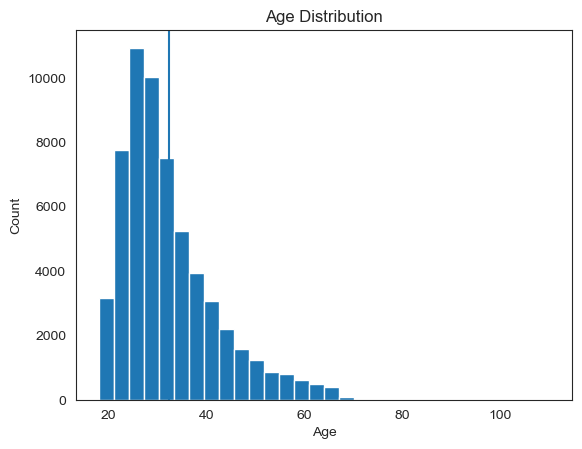

In [99]:
# Calculate mean age
mean_age = df['age'].mean()

# Plot histogram
plt.figure()
plt.hist(df['age'], bins=30)

# Add vertical line for mean
plt.axvline(mean_age)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
# Q2. How does the age distribution differ by gender? Are there age groups where one gender is more prevalent?

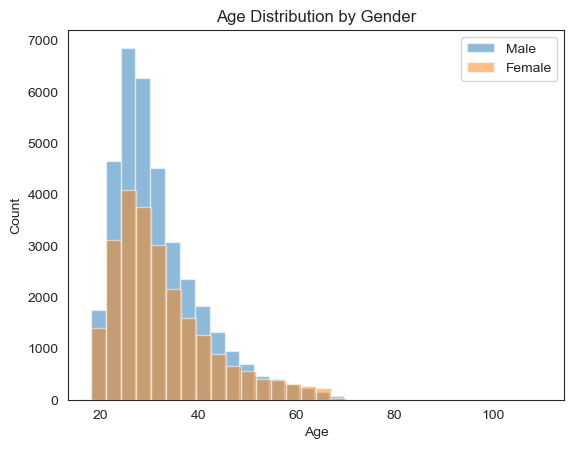

In [100]:
# Separate histograms
plt.figure()

plt.hist(df[df['gender'] == 'm']['age'], bins=30, alpha=0.5, label='Male')
plt.hist(df[df['gender'] == 'f']['age'], bins=30, alpha=0.5, label='Female')

plt.legend()
plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

2. Income and Age

In [ ]:
# Q1. Use a scatterplot to visualize the relationship between income and age, with a trend line indicating overall patterns. Are older users more likely to report higher incomes?

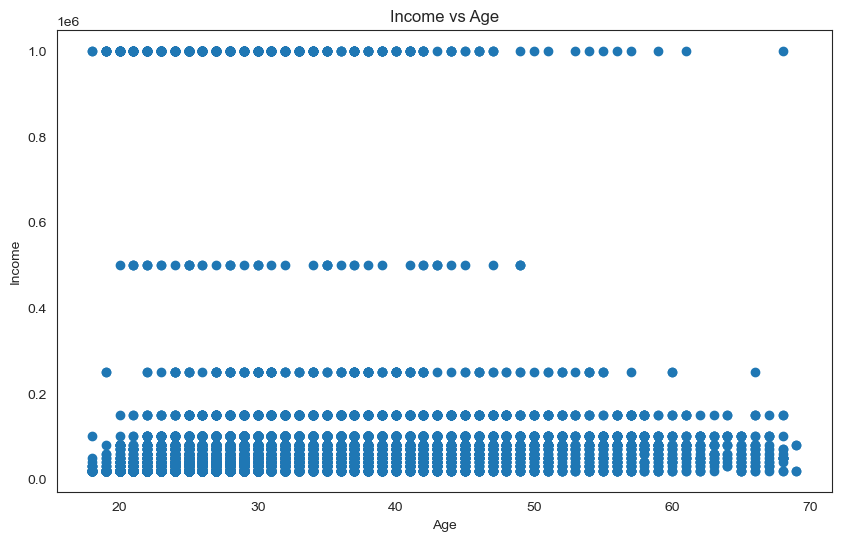

In [102]:
plt.figure(figsize=(10,6))

plt.scatter(df['age'], df['income'])

plt.title("Income vs Age")
plt.xlabel("Age")
plt.ylabel("Income")

plt.show()

In [ ]:
# Q2. Create boxplots of income grouped by age_group. Which age group reports the highest median income?

<Figure size 800x500 with 0 Axes>

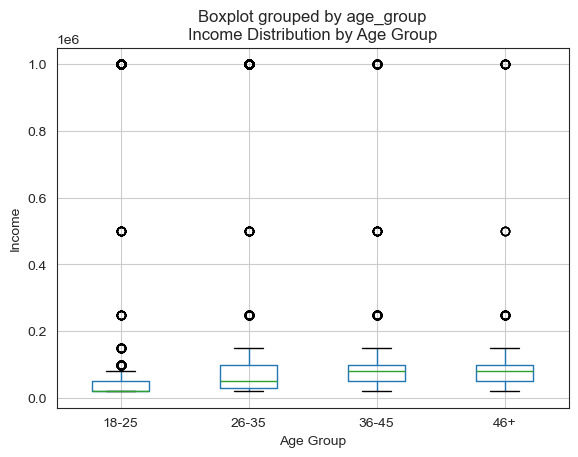

In [104]:
plt.figure(figsize=(8,5))

df.boxplot(column='income', by='age_group')

plt.title("Income Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Income")

plt.show()

<Axes: title={'center': 'income'}, xlabel='age_group'>

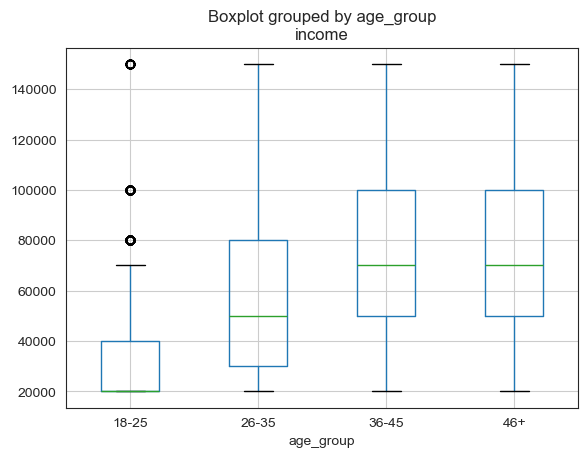

In [105]:
df[df['income'] < 200000].boxplot(column='income', by='age_group')

In [ ]:
# Q3.Analyze income levels within gender and status categories. For example, are single men more likely to report higher incomes than single women?

In [107]:
df_single = df[df['status'] == 'single']
df_single.groupby('gender')['income'].median()

gender
f    40000.0
m    60000.0
Name: income, dtype: float64

In [109]:
df.groupby(['status', 'gender'])['income'].median().unstack()

gender,f,m
status,,
available,30000.0,60000.0
married,30000.0,60000.0
seeing someone,20000.0,40000.0
single,40000.0,60000.0
unknown,20000.0,NaN


3. Pets and Preferences

In [ ]:
# Q1. Create a bar chart showing the distribution of pets categories (e.g., likes dogs, likes cats). Which preferences are most common?

In [110]:
df['pets'].value_counts()

pets
likes dogs and likes cats          14814
likes dogs                          7224
likes dogs and has cats             4313
has dogs                            4134
has dogs and likes cats             2333
likes dogs and dislikes cats        2029
has dogs and has cats               1474
has cats                            1406
likes cats                          1063
has dogs and dislikes cats           552
dislikes dogs and likes cats         240
dislikes dogs and dislikes cats      196
dislikes cats                        122
dislikes dogs and has cats            81
dislikes dogs                         44
Name: count, dtype: int64

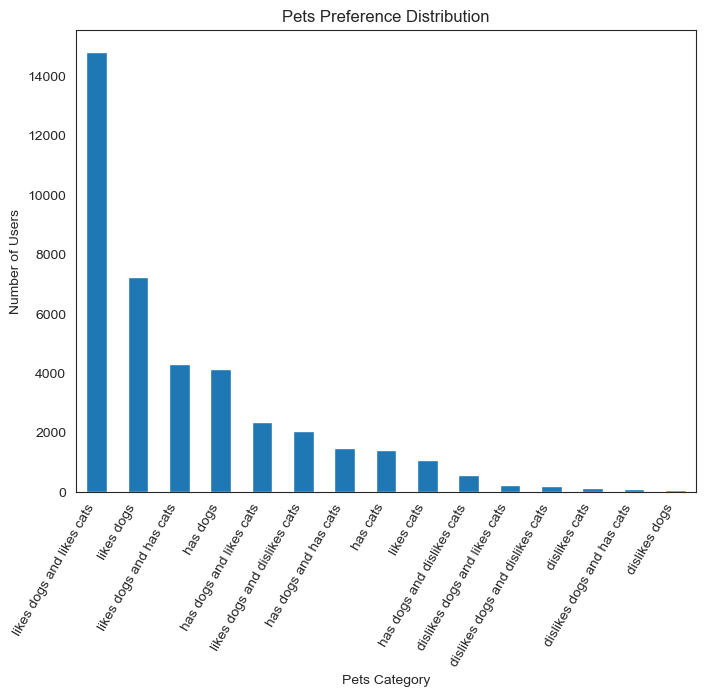

In [113]:
plt.figure(figsize=(8,6))
df['pets'].value_counts().plot(kind='bar')
plt.xticks(rotation=60, ha='right')
plt.title("Pets Preference Distribution")
plt.xlabel("Pets Category")
plt.ylabel("Number of Users")

plt.show()

In [ ]:
# Q2. How do pets preferences vary across gender and age_group? Are younger users more likely to report liking pets compared to older users?

In [114]:
pd.crosstab(df['gender'], df['pets'], normalize='index') * 100

pets,dislikes cats,dislikes dogs,dislikes dogs and dislikes cats,dislikes dogs and has cats,dislikes dogs and likes cats,has cats,has dogs,has dogs and dislikes cats,has dogs and has cats,has dogs and likes cats,likes cats,likes dogs,likes dogs and dislikes cats,likes dogs and has cats,likes dogs and likes cats
gender,,,,,,,,,,,,,,,
f,0.336837,0.127766,0.551716,0.185841,0.435565,4.616993,11.423428,1.823567,5.209362,6.678669,2.015216,15.680353,5.331320,15.012486,30.570881
m,0.280628,0.096466,0.442866,0.214856,0.723494,2.679120,9.501885,1.043585,2.530036,5.187231,3.139525,19.836885,4.871525,7.576953,41.874945


In [ ]:
* Both genders generally prefer pets (especially dogs)

4. Signs and Personality

In [ ]:
# Q1. Create a pie chart showing the distribution of zodiac signs (sign) across the platform. Which signs are most and least represented? Is this the right chart? If not, replace with right chart.

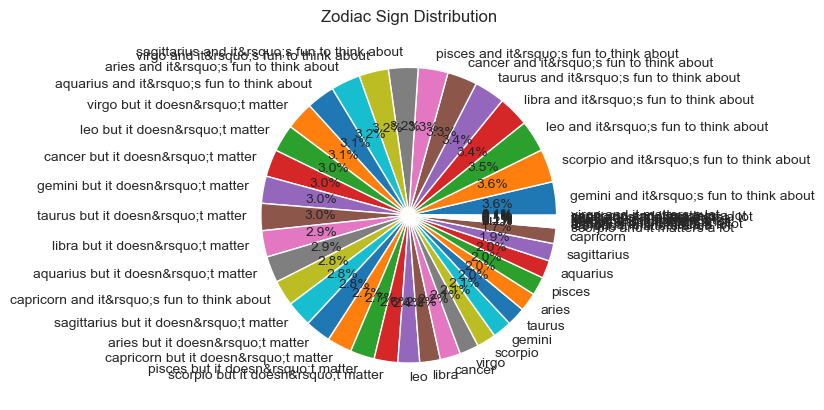

In [119]:
df['sign'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Zodiac Sign Distribution")
plt.ylabel("")
plt.show()

In [ ]:
# Q2. How does sign vary across gender and status? Are there noticeable patterns or imbalances?

In [121]:
df['sign_clean'] = df['sign'].str.split().str[0]

In [123]:
pd.crosstab(df['sign_clean'], df['gender'], normalize='index').round(2) * 100

gender,f,m
sign_clean,,
aquarius,42.0,58.0
aries,43.0,57.0
cancer,41.0,59.0
capricorn,43.0,57.0
gemini,41.0,59.0
leo,41.0,59.0
libra,41.0,59.0
pisces,42.0,58.0
sagittarius,44.0,56.0


In [ ]:
* Most signs appear across all status categories
* No strong relationship between zodiac sign and relationship status